In [16]:
from pathlib import Path

import geopandas as gpd
import pandas as pd
import rasterio
from matplotlib import pyplot as plt
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
)

from estuary.util.img import false_color

In [2]:
def inspect_row(iii, suffix_t, suffix_p):
    _, row = next(iii)

    with rasterio.open(row[f"source_tif{suffix_t}"]) as src:
        data = src.read()
        nodata = src.read(1, masked=True).mask
        t = false_color(data, nodata)

    with rasterio.open(row[f"source_tif{suffix_p}"]) as src:
        data = src.read()
        nodata = src.read(1, masked=True).mask
        p = false_color(data, nodata)

    label_t = row[f"label{suffix_t}"]
    label_p = row[f"label{suffix_p}"]

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[0].set_title(f"Region {row.region} True Label: {label_t}")
    axes[1].set_title(f"Pred Label: {label_p}")

    axes[0].imshow(t)
    axes[0].axis("off")
    axes[1].imshow(p)
    axes[1].axis("off")

    fig.tight_layout()
    plt.show()

In [3]:
BASE = Path("/Volumes/x10pro/estuary/")

In [4]:
gdf = gpd.read_file(BASE / "geos/ca_data_w_empa_pmep_usgs.geojson")
gdf = gdf[~gdf.skipped].copy()
gdf = gdf.set_index("Site code")
gdf.head(3)

,Site name,skipped,PMEP_EstuaryID,Estuary_Name,Data_Source,CMECS_Class,PMEP_Region,System_Order,Estuary_Hectares,Link,...,siteid,point_geom_lat,point_geom_long,pmep_pt_geom_lat,pmep_pt_geom_long,usgs_station_nm,usgs_site_no,usgs_site_latitude,usgs_site_longitude,geometry
Site code,,,,,,,,,,,,,,,,,,,,,
11,Los Penasquitos Lagoon,False,4056.0,Los Penasquitos Lagoon,PMEP,Lagoonal Estuary,Southern California Bight,299.0,95.475975,4056_Los Penasquitos Lagoon,...,SC-LPL,32.933,-117.260,32.931536,-117.256714,None,None,None,None,"POLYGON ((-117.25816 32.93218, -117.25817 32.9..."
18,Zuma Lagoon,False,4018.0,Zuma Canyon,PMEP,Lagoonal Estuary,Southern California Bight,262.0,1.779315,4018_Zuma Canyon,...,SC-ZUM,34.015,-118.821,34.014565,-118.820618,None,None,None,None,"POLYGON ((-118.81685 34.01177, -118.81699 34.0..."
21,Ventura River,False,4010.0,Ventura River,PMEP,Lagoonal Estuary,Southern California Bight,253.0,17.225009,4010_Ventura River,...,SC-VEN,34.276,-119.308,34.277309,-119.308329,None,None,None,None,"POLYGON ((-119.30473 34.27203, -119.3049 34.27..."


In [5]:
ss_df = pd.read_csv("/Volumes/x10pro/estuary/labeling/skysat/labels.csv")
ss_df = ss_df[ss_df.region.isin(gdf.index)].copy()
ss_df = ss_df[ss_df.label != "unsure"].copy()
ss_df["acquired"] = pd.to_datetime(ss_df["acquired"], errors="coerce", utc=True)

ssw_df = pd.read_csv("/Volumes/x10pro/estuary/labeling/skysat_water/labels.csv")
ssw_df = ssw_df[ssw_df.region.isin(gdf.index)].copy()
ssw_df = ssw_df[ssw_df.label != "unsure"].copy()
ssw_df["acquired"] = pd.to_datetime(ssw_df["acquired"], errors="coerce", utc=True)

ss_df.head()

,region,source_tif,label,acquired,instrument,year,month,asset_id
0,11,/Volumes/x10pro/estuary/sat_data/skysat/result...,open,2024-10-20 17:07:34+00:00,skysat,2024,10,20241020_170734_ssc13_u0001
1,11,/Volumes/x10pro/estuary/sat_data/skysat/result...,open,2024-10-21 16:24:30+00:00,skysat,2024,10,20241021_162430_ssc4_u0001
2,14,/Volumes/x10pro/estuary/sat_data/skysat/result...,open,2024-10-22 17:19:42+00:00,skysat,2024,10,20241022_171942_ssc1_u0001
3,15,/Volumes/x10pro/estuary/sat_data/skysat/result...,open,2024-10-22 17:19:42+00:00,skysat,2024,10,20241022_171942_ssc1_u0001
4,16,/Volumes/x10pro/estuary/sat_data/skysat/result...,closed,2024-10-22 17:19:42+00:00,skysat,2024,10,20241022_171942_ssc1_u0001


In [6]:
d_df = pd.read_csv("/Volumes/x10pro/estuary/labeling/dove_split_by_region/labels.csv")
d_df = d_df[d_df.region.isin(gdf.index)].copy()
d_df = d_df[d_df.label != "unsure"].copy()
d_df["acquired"] = pd.to_datetime(d_df["acquired"], errors="coerce", utc=True)

dw_df = pd.read_csv("/Volumes/x10pro/estuary/labeling/dove_water/labels.csv")
dw_df = dw_df[dw_df.region.isin(gdf.index)].copy()
dw_df = dw_df[dw_df.label != "unsure"].copy()
dw_df["acquired"] = pd.to_datetime(dw_df["acquired"], errors="coerce", utc=True)

d_df.head()

,region,source_tif,label,acquired,instrument,year,month,asset_id
0,22,/Volumes/x10pro/estuary/sat_data/dove/results/...,open,2017-01-28 17:55:35+00:00,dove,2017,1,20170128_175535_0e26
1,22,/Volumes/x10pro/estuary/sat_data/dove/results/...,perched open,2017-02-13 17:57:19+00:00,dove,2017,2,20170213_175719_0e0f
2,22,/Volumes/x10pro/estuary/sat_data/dove/results/...,closed,2017-04-15 17:50:47+00:00,dove,2017,4,20170415_175047_1009
3,22,/Volumes/x10pro/estuary/sat_data/dove/results/...,closed,2017-05-08 17:52:59+00:00,dove,2017,5,20170508_175259_0f25
4,22,/Volumes/x10pro/estuary/sat_data/dove/results/...,closed,2017-06-14 17:54:49+00:00,dove,2017,6,20170614_175449_0f52


In [7]:
ss_pairs = pd.merge(
    ss_df, ssw_df, on=["region", "asset_id"], how="inner", suffixes=("_img", "_water")
)
dd_pairs = pd.merge(
    d_df, dw_df, on=["region", "asset_id"], how="inner", suffixes=("_img", "_water")
)

a = ss_df.sort_values("acquired").reset_index(drop=True)
b = d_df.sort_values("acquired").reset_index(drop=True)

# cross-join within region, then filter by window
tmp = pd.merge(
    a,
    b[["source_tif", "asset_id", "region", "label", "acquired"]],
    on="region",
    suffixes=("_ss", "_dd"),
)
tol = pd.Timedelta("10h")
tmp["time_diff"] = (tmp["acquired_dd"] - tmp["acquired_ss"]).abs()
mask = tmp["time_diff"] < tol
d_ss_pairs = tmp.loc[mask].sort_values(["region", "asset_id_ss", "asset_id_dd"])
d_ss_pairs = d_ss_pairs.drop_duplicates(["region", "asset_id_ss"])

len(d_ss_pairs)

477

In [8]:
d_ss_pairs.head()

,region,source_tif_ss,label_ss,acquired_ss,instrument,year,month,asset_id_ss,source_tif_dd,asset_id_dd,label_dd,acquired_dd,time_diff
30474,11,/Volumes/x10pro/estuary/sat_data/skysat/result...,open,2020-08-01 18:45:36+00:00,skysat,2020,8,20200801_184536_ssc1_u0002,/Volumes/x10pro/estuary/sat_data/dove/results/...,20200801_161237_0f2e,open,2020-08-01 16:12:37+00:00,0 days 02:32:59
56105,11,/Volumes/x10pro/estuary/sat_data/skysat/result...,open,2021-11-10 21:35:51+00:00,skysat,2021,11,20211110_213551_ssc6_u0001,/Volumes/x10pro/estuary/sat_data/superdove/res...,20211110_175344_57_227e,open,2021-11-10 17:53:44+00:00,0 days 03:42:07
73182,11,/Volumes/x10pro/estuary/sat_data/skysat/result...,open,2022-06-24 01:30:52+00:00,skysat,2022,6,20220624_013052_ssc18_u0001,/Volumes/x10pro/estuary/sat_data/superdove/res...,20220623_180838_89_2478,open,2022-06-23 18:08:38+00:00,0 days 07:22:14
101001,11,/Volumes/x10pro/estuary/sat_data/skysat/result...,open,2023-06-29 21:52:17+00:00,skysat,2023,6,20230629_215217_ssc6_u0001,/Volumes/x10pro/estuary/sat_data/superdove/res...,20230629_173907_70_24c3,open,2023-06-29 17:39:07+00:00,0 days 04:13:10
59087,14,/Volumes/x10pro/estuary/sat_data/skysat/result...,closed,2021-12-15 18:44:53+00:00,skysat,2021,12,20211215_184453_ssc1_u0001,/Volumes/x10pro/estuary/sat_data/superdove/res...,20211215_182546_45_2424,closed,2021-12-15 18:25:46+00:00,0 days 00:19:07


In [12]:
d_ss_pairs.label_ss.value_counts()

label_ss
closed          233
open            203
perched open     41
Name: count, dtype: int64

Accuracy 3 class 77.6
Perched F1 44.2
Accuracy Open/Closed 96.9
Accuracy No Perch 99.5


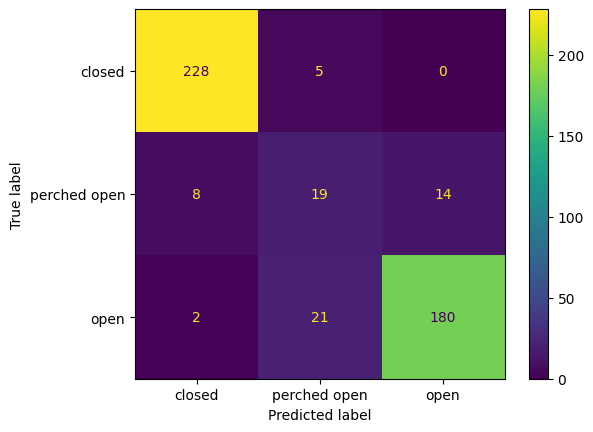

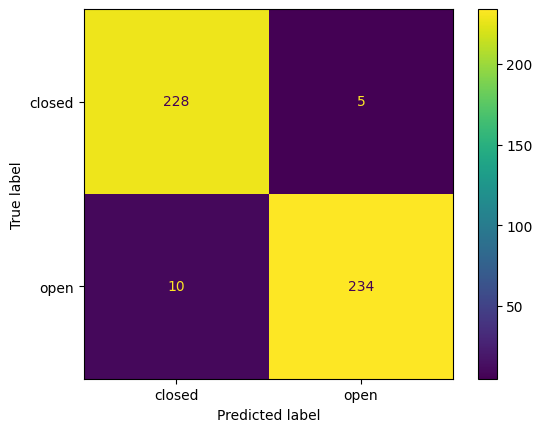

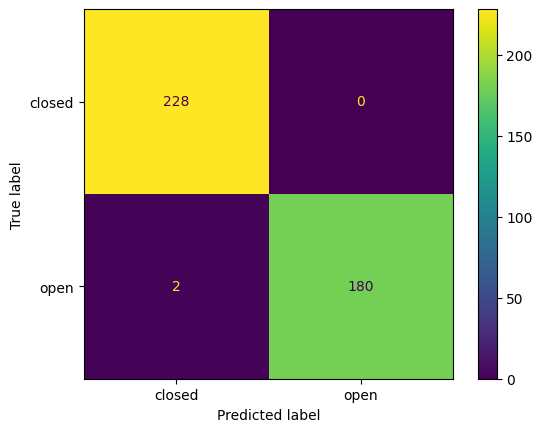

In [18]:
labels = ["closed", "perched open", "open"]
y_true = np.array([labels.index(l) for l in d_ss_pairs.label_ss])
y_pred = np.array([labels.index(l) for l in d_ss_pairs.label_dd])

print("Accuracy 3 class", round(100 * balanced_accuracy_score(y_true, y_pred), 1))
print("Perched F1", round(100 * f1_score(y_true == 1, y_pred == 1), 1))
ConfusionMatrixDisplay.from_predictions(y_true, y_pred, display_labels=labels)

labels = ["closed", "open"]
y_true = [int("open" in l) for l in d_ss_pairs.label_ss]
y_pred = [int("open" in l) for l in d_ss_pairs.label_dd]

print("Accuracy Open/Closed", round(100 * balanced_accuracy_score(y_true, y_pred), 1))

ConfusionMatrixDisplay.from_predictions(y_true, y_pred, display_labels=labels)

labels = ["closed", "open"]
y_true = [
    int("open" in l)
    for l, p in zip(d_ss_pairs.label_ss, d_ss_pairs.label_dd)
    if "perch" not in l and "perch" not in p
]
y_pred = [
    int("open" in p)
    for l, p in zip(d_ss_pairs.label_ss, d_ss_pairs.label_dd)
    if "perch" not in l and "perch" not in p
]

print("Accuracy No Perch", round(100 * balanced_accuracy_score(y_true, y_pred), 1))

ConfusionMatrixDisplay.from_predictions(y_true, y_pred, display_labels=labels)

In [19]:
# inspect = pd.concat([
#     d_ss_pairs[(d_ss_pairs.label_ss == "closed") & (d_ss_pairs.label_dd == "open")],
#     d_ss_pairs[(d_ss_pairs.label_ss == "open") & (d_ss_pairs.label_dd == "closed")]
# ])
inspect = d_ss_pairs[(d_ss_pairs.label_ss == "open") & (d_ss_pairs.label_dd == "closed")]
inspect_iter = inspect.iterrows()

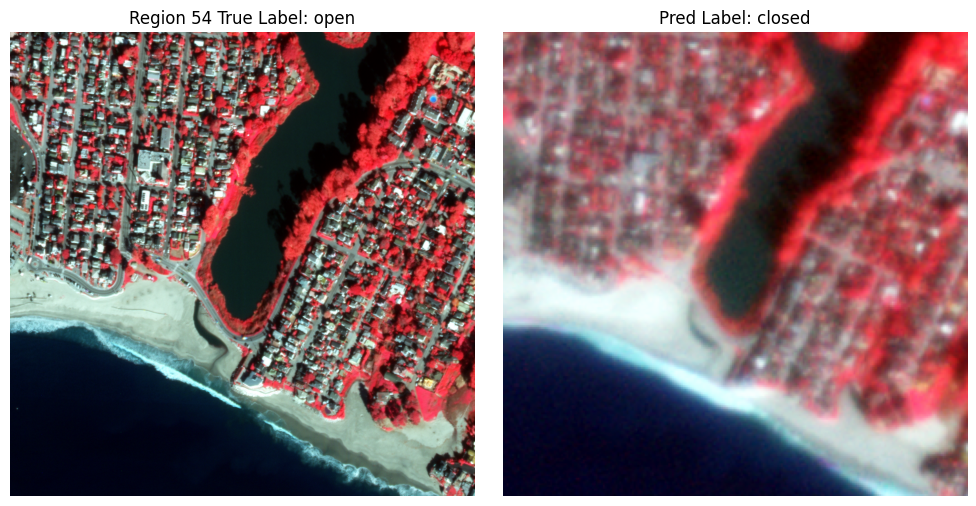

In [20]:
inspect_row(inspect_iter, "_ss", "_dd")

In [26]:
dd_pairs.label_water.value_counts()

label_water
closed          547
open            522
perched open     73
Name: count, dtype: int64

1142
Accuracy 3 class 82.6
Perched F1 60.7
Accuracy Open/Closed 98.5
Accuracy No Perch 99.7
pct perched either 7.4


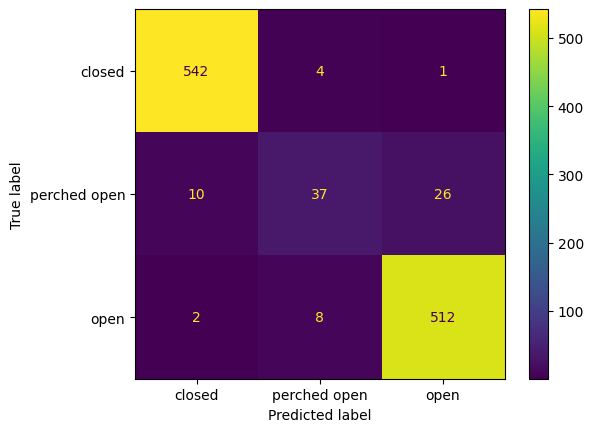

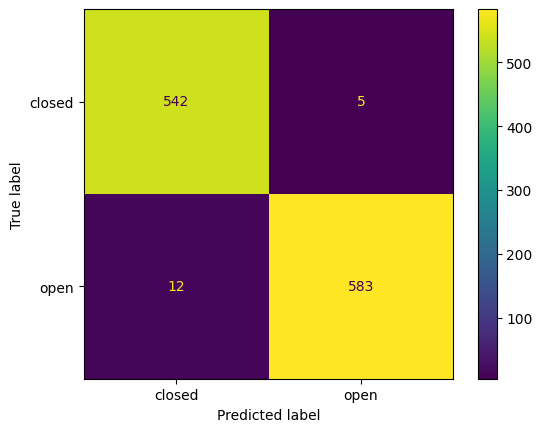

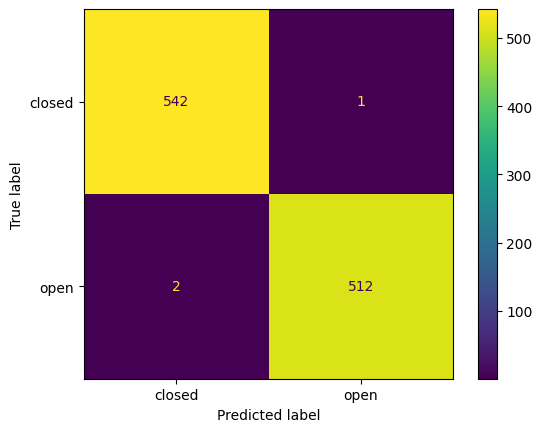

In [24]:
print(len(dd_pairs))

labels = ["closed", "perched open", "open"]
y_true = np.array([labels.index(l) for l in dd_pairs.label_water])
y_pred = np.array([labels.index(l) for l in dd_pairs.label_img])

print("Accuracy 3 class", round(100 * balanced_accuracy_score(y_true, y_pred), 1))
print("Perched F1", round(100 * f1_score(y_true == 1, y_pred == 1), 1))

ConfusionMatrixDisplay.from_predictions(y_true, y_pred, display_labels=labels)

labels = ["closed", "open"]
y_true = [int("open" in l) for l in dd_pairs.label_water]
y_pred = [int("open" in l) for l in dd_pairs.label_img]

print("Accuracy Open/Closed", round(100 * balanced_accuracy_score(y_true, y_pred), 1))

ConfusionMatrixDisplay.from_predictions(y_true, y_pred, display_labels=labels)

labels = ["closed", "open"]
y_true = [
    int("open" in l)
    for l, p in zip(dd_pairs.label_water, dd_pairs.label_img)
    if "perch" not in l and "perch" not in p
]
y_pred = [
    int("open" in p)
    for l, p in zip(dd_pairs.label_water, dd_pairs.label_img)
    if "perch" not in l and "perch" not in p
]

print("Accuracy No Perch", round(100 * balanced_accuracy_score(y_true, y_pred), 1))
print("pct perched either", round(100 - 100 * len(y_pred) / len(dd_pairs), 1))

ConfusionMatrixDisplay.from_predictions(y_true, y_pred, display_labels=labels)

In [16]:
# inspect_d = pd.concat(
#     [
#         dd_pairs[(dd_pairs.label_water == "closed") & (dd_pairs.label_img == "open")],
#         dd_pairs[(dd_pairs.label_water == "open") & (dd_pairs.label_img == "closed")],
#     ]
# )
inspect_d = dd_pairs[(dd_pairs.label_water == "perched open") & (dd_pairs.label_img == "closed")]
inspect_d_iter = inspect_d.iterrows()

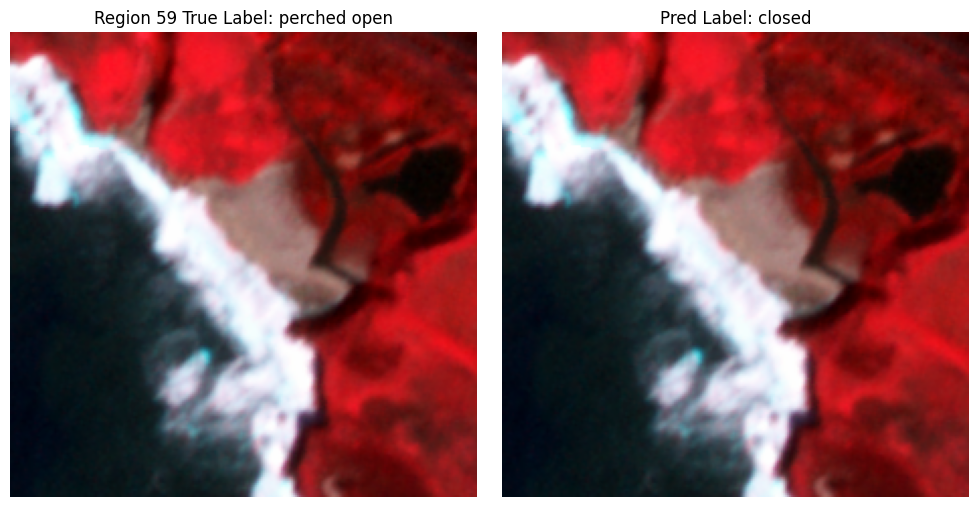

In [29]:
inspect_row(inspect_d_iter, "_water", "_img")

Accuracy 3 class 100.0
Accuracy Open/Closed 100.0


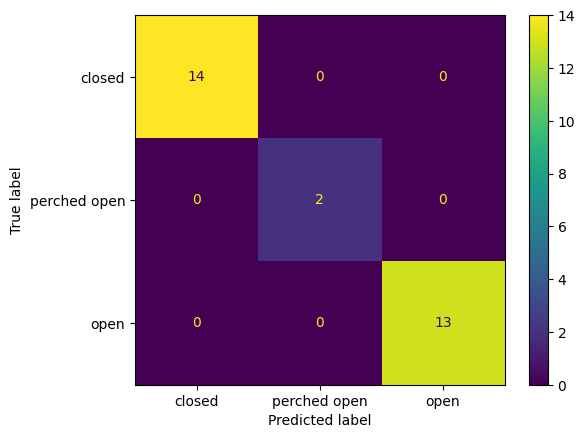

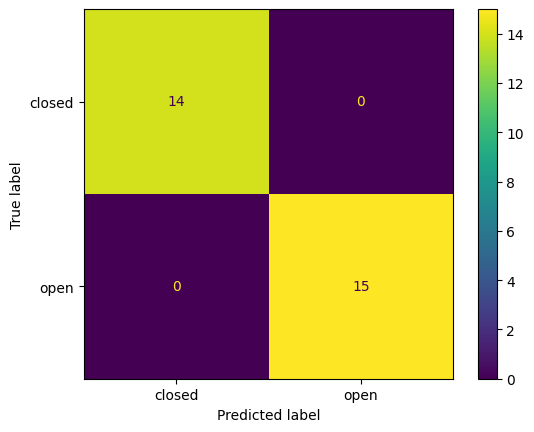

In [15]:
labels = ["closed", "perched open", "open"]
y_true = [labels.index(l) for l in ss_pairs.label_water]
y_pred = [labels.index(l) for l in ss_pairs.label_img]

print("Accuracy 3 class", round(100 * accuracy_score(y_true, y_pred), 1))

ConfusionMatrixDisplay.from_predictions(y_true, y_pred, display_labels=labels)

labels = ["closed", "open"]
y_true = [int("open" in l) for l in ss_pairs.label_water]
y_pred = [int("open" in l) for l in ss_pairs.label_img]

print("Accuracy Open/Closed", round(100 * accuracy_score(y_true, y_pred), 1))

ConfusionMatrixDisplay.from_predictions(y_true, y_pred, display_labels=labels)